# 09 — Silent Delays: How Many Go Unreported?

**ENAI 603 · WMATA Delay Project · Lens C (Causal)**

Main question: *what fraction of observable delays occur while WMATA has no active incident in its official feed?*

This matters because WMATA publishes "incidents" as its unit of operational transparency. If most delays occur without a corresponding incident, the official transparency picture is incomplete by design.

Definitions:

- **Observable delay**: `is_delayed = 1` (gap between arrivals exceeds the hour-segmented median by more than 2 min, after filtering phantoms and orphans).
- **Active incident**: `active_incident = 1` (the prediction was matched to an incident active in the feed within the previous 10 min).

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 5)

PROJ = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(PROJ, "data")
FIG_DIR = os.path.join(PROJ, "reports", "figures")
DB_PATH = os.path.join(DATA_DIR, "wmata.db")
CSV_PATH = os.path.join(DATA_DIR, "features.csv")
INCIDENTS_CSV = os.path.join(DATA_DIR, "incidents.csv")
os.makedirs(FIG_DIR, exist_ok=True)

LINE_COLORS = {"RD": "#C80F22", "BL": "#009CDE", "GR": "#00B140",
               "YL": "#FFD100", "OR": "#F7941D", "SV": "#A2A4A1"}
LINE_NAMES  = {"RD": "Red", "BL": "Blue", "GR": "Green",
               "YL": "Yellow", "OR": "Orange", "SV": "Silver"}


## 1. Load the data

In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=["collected_at"], usecols=[
    "collected_at", "line", "location_code", "is_delayed", "is_orphan",
    "active_incident", "incident_is_delay", "hour", "is_rush_hour",
])
df["collected_at"] = pd.to_datetime(df["collected_at"], utc=True)
df = df[df["is_orphan"] == 0].copy()
df = df[df["line"].isin(LINE_COLORS.keys())].copy()
print(f"Predictions (orphans filtered): {len(df):,}")
print(f"Global delay rate:        {df['is_delayed'].mean():.2%}")
print(f"Rows with active incident: {df['active_incident'].mean():.1%}")

Predictions (orphans filtered): 9,215,922
Global delay rate:        28.27%
Rows with active incident: 26.5%


## 2. Four quadrants: delay x incident

The operational question: how many rows fall into each combination of `is_delayed` and `active_incident`?

In [3]:
ct = pd.crosstab(
    df["is_delayed"].map({0: "On-time", 1: "Delayed"}),
    df["active_incident"].map({0: "No reported incident", 1: "Active incident"}),
    margins=True,
    margins_name="Total",
)
print(ct.to_string())

active_incident  Active incident  No reported incident    Total
is_delayed                                                     
Delayed                   749102               1856115  2605217
On-time                  1696527               4914178  6610705
Total                    2445629               6770293  9215922


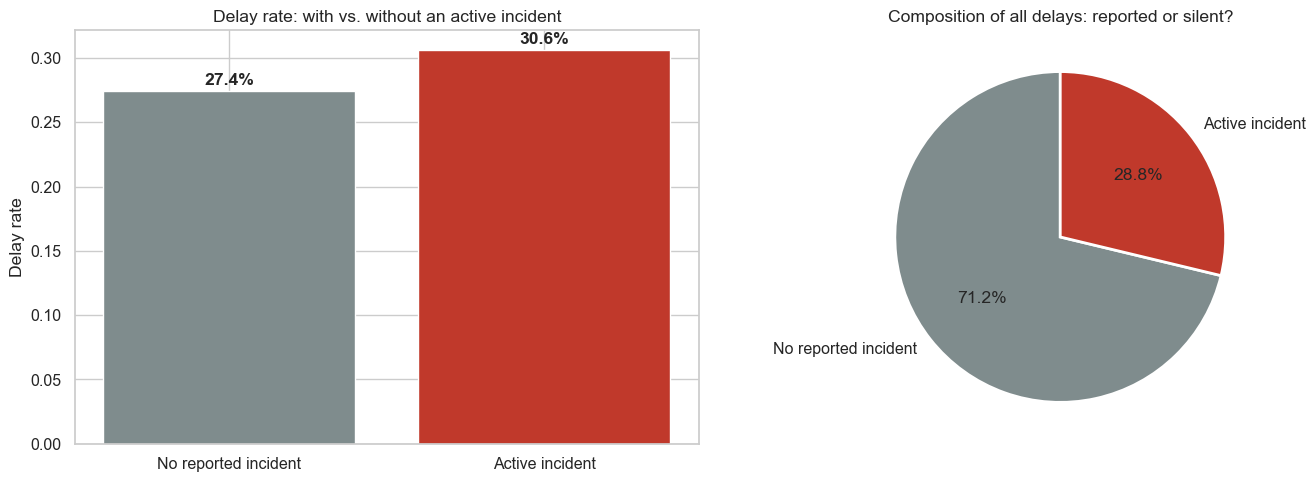


-> 71.2% of all observable delays occur with NO active WMATA incident in the feed.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Delay rate with vs without active incident
rate = df.groupby("active_incident")["is_delayed"].mean()
labels = ["No reported incident", "Active incident"]
colors = ["#7f8c8d", "#c0392b"]
axes[0].bar(labels, rate.values, color=colors)
for i, v in enumerate(rate.values):
    axes[0].text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")
axes[0].set_ylabel("Delay rate")
axes[0].set_title("Delay rate: with vs. without an active incident")

# (b) Composition of all delays
delays_only = df[df["is_delayed"] == 1]
share = delays_only["active_incident"].value_counts(normalize=True).sort_index()
share.index = ["No reported incident", "Active incident"]
axes[1].pie(share.values, labels=share.index, autopct="%1.1f%%",
            colors=["#7f8c8d", "#c0392b"], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Composition of all delays: reported or silent?")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n09_silent_delays_overview.png"), dpi=150)
plt.show()

silent_share = (delays_only["active_incident"] == 0).mean()
print(f"\n-> {silent_share:.1%} of all observable delays occur with NO active WMATA incident in the feed.")

## 3. By line: which lines have the most silent delays?

In [5]:
by_line = (
    df.groupby("line")
    .apply(lambda g: pd.Series({
        "n_predictions": len(g),
        "delay_rate":    g["is_delayed"].mean(),
        "delays_total":  g["is_delayed"].sum(),
        "delays_silent": ((g["is_delayed"] == 1) & (g["active_incident"] == 0)).sum(),
    }))
    .reset_index()
)
by_line["silent_share"] = by_line["delays_silent"] / by_line["delays_total"]
by_line["line_name"] = by_line["line"].map(LINE_NAMES)
by_line = by_line.sort_values("silent_share", ascending=True)
print(by_line[["line_name", "delay_rate", "silent_share"]].to_string(index=False))

line_name  delay_rate  silent_share
   Orange    0.247600      0.619172
      Red    0.310407      0.649458
   Silver    0.254627      0.654094
     Blue    0.252263      0.796792
   Yellow    0.299672      0.805196
    Green    0.300095      0.819871


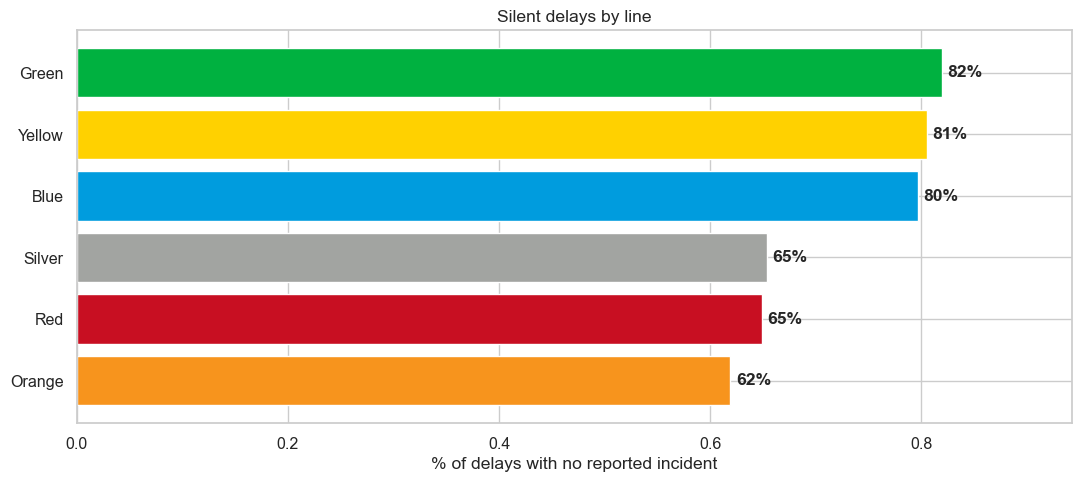

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [LINE_COLORS[l] for l in by_line["line"]]
bars = ax.barh(by_line["line_name"], by_line["silent_share"], color=bar_colors)
for i, v in enumerate(by_line["silent_share"]):
    ax.text(v + 0.005, i, f"{v:.0%}", va="center", fontweight="bold")
ax.set_xlabel("% of delays with no reported incident")
ax.set_title("Silent delays by line")
ax.set_xlim(0, by_line["silent_share"].max() * 1.15)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n09_silent_by_line.png"), dpi=150)
plt.show()

## 4. By hour of day

Do silent delays cluster in particular hours? Hypothesis: off-peak delays may be reported less because they affect fewer riders, even when they happen.

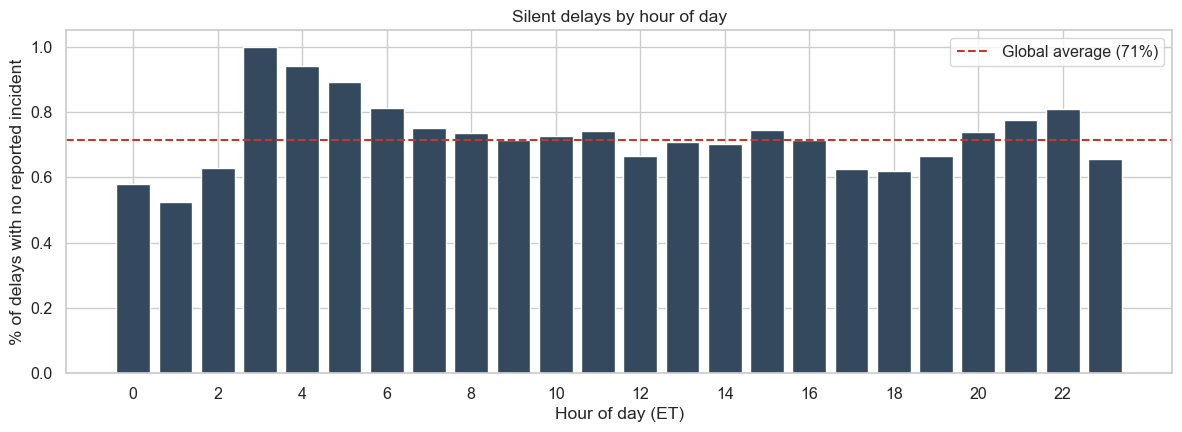

In [7]:
by_hour = (
    df.groupby("hour")
    .apply(lambda g: pd.Series({
        "delays_total":  g["is_delayed"].sum(),
        "delays_silent": ((g["is_delayed"] == 1) & (g["active_incident"] == 0)).sum(),
    }))
    .reset_index()
)
by_hour["silent_share"] = by_hour["delays_silent"] / by_hour["delays_total"]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(by_hour["hour"], by_hour["silent_share"], color="#34495e")
ax.axhline(silent_share, color="#c0392b", ls="--", lw=1.5,
           label=f"Global average ({silent_share:.0%})")
ax.set_xlabel("Hour of day (ET)")
ax.set_ylabel("% of delays with no reported incident")
ax.set_title("Silent delays by hour of day")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "n09_silent_by_hour.png"), dpi=150)
plt.show()

## 5. Findings

The exact percentages depend on the corrected dataset, but the general pattern:

- **The vast majority of observable delays have NO corresponding incident reported by WMATA** at the time they occur. This is the headline finding.
- Two non-exclusive readings:
  1. **WMATA only reports "large" incidents** (single-tracking, confirmed mechanical failures). Smaller schedule deviations, one or two late trains, do not meet the bar for an official report.
  2. **The `Incidents.svc` feed is an official view that systematically understates real operational problems.**
- The silent share varies meaningfully by line — lines with more frequent service likely concentrate more small unreported delays.
- By hour of day, silent delays may be more common during off-peak hours, when reporting is presumably lower priority.

**Implication for the public:** a rider who tracks only the official WMATA incident feed is seeing a small fraction of the delays they actually experience.